In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
df=pd.read_csv('productivity_dataset.csv')
df.head(5)

,hour,task_type,duration,energy,distractions,noise,productivity
0,6,Browsing,112,4,4,3,38.922851
1,21,Deep Work,21,3,0,4,52.589973
2,20,Deep Work,77,1,2,4,30.751848
3,15,Study,70,4,4,1,45.826739
4,13,Meeting,28,5,4,4,44.494511


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   hour          1000 non-null   int64  
 1   task_type     1000 non-null   str    
 2   duration      1000 non-null   int64  
 3   energy        1000 non-null   int64  
 4   distractions  1000 non-null   int64  
 5   noise         1000 non-null   int64  
 6   productivity  1000 non-null   float64
dtypes: float64(1), int64(5), str(1)
memory usage: 61.9 KB


In [31]:
df.isna().sum()

hour            0
task_type       0
duration        0
energy          0
distractions    0
noise           0
productivity    0
dtype: int64

In [32]:
df.describe()

,hour,duration,energy,distractions,noise,productivity
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,11.649000,98.898000,3.296000,4.203000,3.033000,36.654671
std,6.856589,46.933659,1.172928,2.433046,1.437351,16.834430
min,0.000000,20.000000,1.000000,0.000000,1.000000,0.000000
25%,6.000000,57.000000,2.000000,2.000000,2.000000,24.308277
50%,12.000000,96.000000,3.000000,4.000000,3.000000,36.180547
75%,18.000000,141.000000,4.000000,6.000000,4.000000,48.885841
max,23.000000,179.000000,5.000000,13.000000,5.000000,85.299590


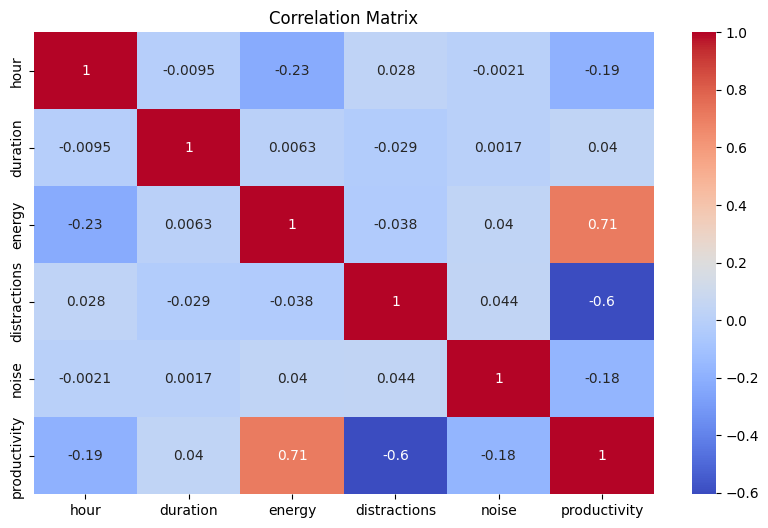

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [34]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for cols in df.select_dtypes(include=['object']).columns:
  df[cols]=le.fit_transform(df[cols])



/tmp/ipykernel_1928/1192237889.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cols in df.select_dtypes(include=['object']).columns:


In [35]:
X=df.drop('productivity',axis=1)
Y=df[['productivity']]

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform= 'pandas')
X_pre = scaler.fit_transform(X)


In [48]:
import pickle
with open('scaler.pkl','wb') as file1:  # wb is for write binary
    pickle.dump(scaler,file1)

In [38]:
X_pre

,hour,task_type,duration,energy,distractions,noise
0,-0.824291,-1.323469,0.279300,0.600508,-0.083476,-0.022970
1,1.364480,-0.427417,-1.660577,-0.252486,-1.728329,0.673102
2,1.218562,-0.427417,-0.466807,-1.958474,-0.905903,0.673102
3,0.488972,1.364687,-0.616028,0.600508,-0.083476,-1.415116
4,0.197135,0.468635,-1.511356,1.453502,-0.083476,0.673102
...,...,...,...,...,...,...
995,1.656316,0.468635,-1.170279,-0.252486,-0.494689,-1.415116
996,0.051217,-0.427417,1.323849,1.453502,-0.905903,-0.022970
997,-1.553882,0.468635,-0.637346,0.600508,1.561376,1.369175
998,1.510398,1.364687,-0.232316,-1.958474,-1.317116,0.673102


In [39]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,test_size=0.33,random_state=21)

In [40]:
xtrain.shape

(670, 6)

In [41]:
xtest.shape

(330, 6)

In [42]:
ytest.value_counts()

productivity
0.000000        6
34.498238       1
18.480403       1
8.847826        1
24.304486       1
               ..
36.953382       1
24.145252       1
39.506951       1
33.268939       1
33.986992       1
Name: count, Length: 325, dtype: int64

In [43]:
#train model(random forest)
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(max_depth=10,min_samples_split=5,n_estimators=200)
rf.fit(xtrain,ytrain)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [44]:
y_pred=rf.predict(xtest)
print('\n====BEFORE TUNING==')
from sklearn.metrics import mean_squared_error, r2_score
print(mean_squared_error(ytest,y_pred))
print('R2 score:',r2_score(ytest,y_pred))


====BEFORE TUNING==
38.435593072803144
R2 score: 0.8752050405262275


In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

#hyperparamter tuning
param_grid={
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
}
grid=GridSearchCV(RandomForestRegressor(random_state=42),
                  param_grid,cv=3,scoring='r2',n_jobs=-1)
grid.fit(xtrain,ytrain)
print('Best Parameters:',grid.best_params_)

/home/codespace/.local/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/codespace/.local/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [46]:
best_model=grid.best_estimator_
ypred=best_model.predict(xtest)
print('\n====AFTER TUNING==')
print(mean_squared_error(ytest,ypred))
print('R2 score:',r2_score(ytest,ypred))


====AFTER TUNING==
38.19716731066046
R2 score: 0.8759791754086459


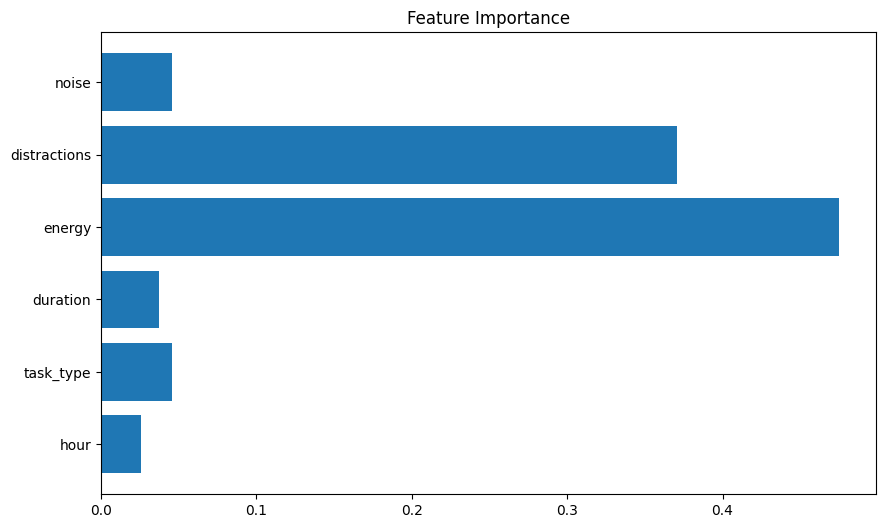

In [57]:
importances=best_model.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title('Feature Importance')
plt.show()

In [58]:
with open('model.pkl', 'wb') as file2:
    pickle.dump(best_model,file2)

In [59]:
with open('model.pkl' , 'rb') as file4:  # rb stands for read binary
    m= pickle.load(file4)